# Sentinel-1 GRD Geolocation Verification

Verifies that the EOPFZARR driver correctly geolocates Sentinel-1 GRD products using Ground Control Points (GCPs).

This notebook checks both the **multi-band wrapper** (default `GRD_MULTIBAND=YES`) and **individual subdatasets** to confirm they report valid WGS84 GCPs and can be warped to a geographic projection.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

gdal.UseExceptions()

# Retry on transient HTTP errors (common with large remote Zarr tiles)
gdal.SetConfigOption('GDAL_HTTP_MAX_RETRY', '5')
gdal.SetConfigOption('GDAL_HTTP_RETRY_DELAY', '2')

drv = gdal.GetDriverByName('EOPFZARR')
assert drv is not None, 'EOPFZARR driver not found — install the plugin first'
print(f'GDAL {gdal.__version__} | EOPFZARR driver: OK')

GDAL 3.12.0dev-209c099c56 | EOPFZARR driver: OK


In [17]:
GRD_URL = (
    "/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "202602-s01siwgrh-global/05/products/cpm_v262/"
    "S1C_IW_GRDH_1SDV_20260205T120122_20260205T120158_006220_00C7E4_5D6E.zarr"
)

## 1. Multi-Band GRD — GCPs present?

In [14]:
ds_mb = gdal.Open(f"EOPFZARR:'{GRD_URL}'")
assert ds_mb is not None, 'Failed to open multi-band GRD'

print(f'Bands:     {ds_mb.RasterCount}  ({", ".join(ds_mb.GetRasterBand(i+1).GetDescription() for i in range(ds_mb.RasterCount))})')
print(f'Size:      {ds_mb.RasterXSize} x {ds_mb.RasterYSize}')
print(f'GCP count: {ds_mb.GetGCPCount()}')

srs = ds_mb.GetGCPSpatialRef()
print(f'GCP SRS:   {srs.GetName() if srs else "NONE"}')

assert ds_mb.GetGCPCount() > 0, 'No GCPs on multi-band dataset!'
assert srs is not None and srs.IsGeographic(), 'GCP SRS is not geographic!'

gcps = ds_mb.GetGCPs()
lons = [g.GCPX for g in gcps]
lats = [g.GCPY for g in gcps]
print(f'Extent:    lon [{min(lons):.3f}, {max(lons):.3f}]  lat [{min(lats):.3f}, {max(lats):.3f}]')
print('\n✓ Multi-band GRD has valid WGS84 GCPs')

Bands:     2  (VV, VH)
Size:      25157 x 24285
GCP count: 294
GCP SRS:   WGS 84
Extent:    lon [-94.146, -91.415]  lat [14.042, 16.665]

✓ Multi-band GRD has valid WGS84 GCPs


## 2. Warp Multi-Band GRD to WGS84

Uses GCPs to reproject to a regular geographic grid. Downsampled to 512px wide for speed.

In [15]:
warped = gdal.Warp(
    '', ds_mb,
    format='MEM',
    dstSRS='EPSG:4326',
    width=256, height=0,   # small output — just enough to verify geolocation
    resampleAlg='near',
)
assert warped is not None, 'Warp failed'

gt = warped.GetGeoTransform()
print(f'Warped size:   {warped.RasterXSize} x {warped.RasterYSize} px')
print(f'Origin:        lon={gt[0]:.4f}  lat={gt[3]:.4f}')
print(f'Pixel size:    {gt[1]:.6f}° x {abs(gt[5]):.6f}°')

# Sanity check: origin should be near Central America
assert -100 < gt[0] < -85, f'Unexpected longitude {gt[0]}'
assert 13 < gt[3] < 20, f'Unexpected latitude {gt[3]}'
print('\n✓ Warped output is correctly positioned over Central America')

Warped size:   256 x 248 px
Origin:        lon=-94.1436  lat=16.6649
Pixel size:    0.010573° x 0.010573°

✓ Warped output is correctly positioned over Central America


## 3. Visualize — SAR Backscatter in Geographic Space

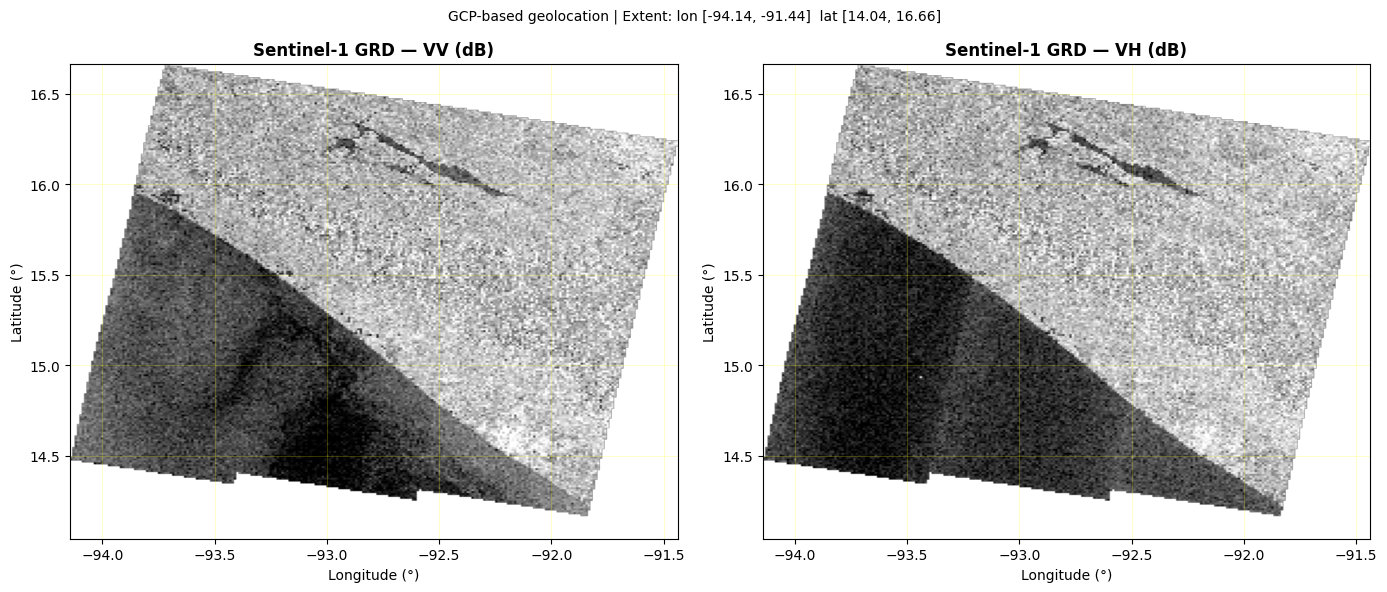

✓ SAR data correctly displayed in geographic coordinates


In [5]:
try:
    vv = warped.GetRasterBand(1).ReadAsArray().astype(np.float32)
    vh = warped.GetRasterBand(2).ReadAsArray().astype(np.float32)

    # Convert to dB
    def to_db(arr):
        arr = np.where(arr > 0, arr, np.nan)
        return 10 * np.log10(arr)

    vv_db, vh_db = to_db(vv), to_db(vh)

    extent = [
        gt[0],
        gt[0] + gt[1] * warped.RasterXSize,
        gt[3] + gt[5] * warped.RasterYSize,
        gt[3],
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, data, title in zip(axes, [vv_db, vh_db], ['VV (dB)', 'VH (dB)']):
        vmin, vmax = np.nanpercentile(data, [2, 98])
        ax.imshow(data, cmap='gray', vmin=vmin, vmax=vmax, extent=extent, aspect='auto')
        ax.set_title(f'Sentinel-1 GRD — {title}', fontweight='bold')
        ax.set_xlabel('Longitude (°)')
        ax.set_ylabel('Latitude (°)')
        ax.grid(True, alpha=0.3, color='yellow', linewidth=0.5)

    plt.suptitle(
        f'GCP-based geolocation | Extent: lon [{extent[0]:.2f}, {extent[1]:.2f}]'
        f'  lat [{extent[2]:.2f}, {extent[3]:.2f}]',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()
    print('✓ SAR data correctly displayed in geographic coordinates')

except Exception as e:
    print(f'Plot skipped: {e}')

warped = None
ds_mb = None

## Download and visualize the warped multi-band GRD product to confirm it looks correct in geographic space.

In [3]:
import zarr

src_url = (
    "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "202602-s01siwgrh-global/05/products/cpm_v262/"
    "S1C_IW_GRDH_1SDV_20260205T120122_20260205T120158_006220_00C7E4_5D6E.zarr"
)
local_path = "/home/yadagale/work/gdal-zarr-eopf/GDAL-ZARR-EOPF/docs/s1_grd_local.zarr"

# SDV = dual-pol VV+VH; product group names follow S01SIWGRD_..._<POL> pattern
product_keys = [
    "S01SIWGRD_20260205T120122_0036_C036_5D6E_00C7E4_VV",
    "S01SIWGRD_20260205T120122_0036_C036_5D6E_00C7E4_VH",
]

src_root = zarr.open(src_url, mode='r')
dst_root = zarr.open_group(zarr.DirectoryStore(local_path), mode='w')

for product_key in product_keys:
    src_prod = src_root[product_key]

    # Copy each GCP array explicitly — zarr.copy on a group doesn't recurse in zarr v3
    gcp_src = src_prod["conditions/gcp"]
    gcp_dst = dst_root.require_group(f"{product_key}/conditions/gcp")
    for arr_name in ['pixel', 'line', 'latitude', 'longitude', 'height']:
        zarr.copy(gcp_src[arr_name], gcp_dst, name=arr_name)
        print(f"  [{product_key[-2:]}] copied gcp/{arr_name}: shape={gcp_src[arr_name].shape}")

    # Copy a 2048x2048 subset of the measurement array
    src_arr = src_prod["measurements/grd"]
    dst_arr = dst_root.require_dataset(
        f"{product_key}/measurements/grd",
        shape=src_arr.shape, chunks=src_arr.chunks,
        dtype=src_arr.dtype,
    )
    dst_arr[:2048, :2048] = src_arr[:2048, :2048]
    print(f"  [{product_key[-2:]}] copied measurements/grd: 2048x2048 of {src_arr.shape}")

print("Done")

  [VV] copied gcp/pixel: shape=(21,)
  [VV] copied gcp/line: shape=(14,)
  [VV] copied gcp/latitude: shape=(14, 21)
  [VV] copied gcp/longitude: shape=(14, 21)
  [VV] copied gcp/height: shape=(14, 21)
  [VV] copied measurements/grd: 2048x2048 of (24285, 25157)
  [VH] copied gcp/pixel: shape=(21,)
  [VH] copied gcp/line: shape=(14,)
  [VH] copied gcp/latitude: shape=(14, 21)
  [VH] copied gcp/longitude: shape=(14, 21)
  [VH] copied gcp/height: shape=(14, 21)
  [VH] copied measurements/grd: 2048x2048 of (24285, 25157)
Done


Bands:     2  (VV, VH)
Size:      25157 x 24285
GCP count: 294
GCP SRS:   WGS 84
Full extent: lon [-94.146, -91.415]  lat [14.042, 16.665]
Data extent: lon [-91.581, -91.415]  lat [16.053, 16.256]
Warped origin: lon=-91.6314  lat=16.3058


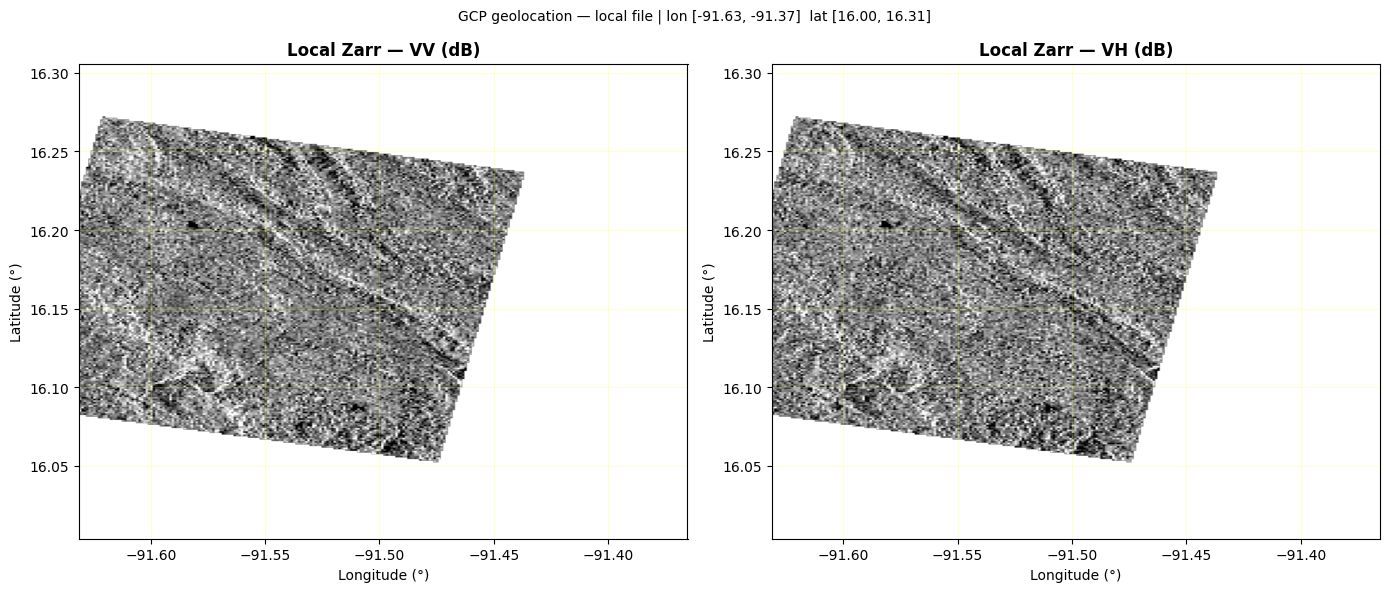

✓ Local Zarr correctly geolocated via GCPs


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

gdal.UseExceptions()

local_path = "/home/yadagale/work/gdal-zarr-eopf/GDAL-ZARR-EOPF/docs/s1_grd_local.zarr"
ds_local = gdal.Open(f"EOPFZARR:'{local_path}'")
assert ds_local is not None, "Failed to open local Zarr"

print(f"Bands:     {ds_local.RasterCount}  ({', '.join(ds_local.GetRasterBand(i+1).GetDescription() for i in range(ds_local.RasterCount))})")
print(f"Size:      {ds_local.RasterXSize} x {ds_local.RasterYSize}")
print(f"GCP count: {ds_local.GetGCPCount()}")

srs = ds_local.GetGCPSpatialRef()
print(f"GCP SRS:   {srs.GetName() if srs else 'NONE'}")

gcps = ds_local.GetGCPs()
lons = [g.GCPX for g in gcps]
lats = [g.GCPY for g in gcps]
print(f"Full extent: lon [{min(lons):.3f}, {max(lons):.3f}]  lat [{min(lats):.3f}, {max(lats):.3f}]")

# Only 2048x2048 pixels were downloaded — compute bounds from GCPs within that region
DOWNLOADED_PIXELS = 2048
subset_gcps = [g for g in gcps if g.GCPPixel <= DOWNLOADED_PIXELS and g.GCPLine <= DOWNLOADED_PIXELS]
pad = 0.05
bounds = [
    min(g.GCPX for g in subset_gcps) - pad,
    min(g.GCPY for g in subset_gcps) - pad,
    max(g.GCPX for g in subset_gcps) + pad,
    max(g.GCPY for g in subset_gcps) + pad,
]
print(f"Data extent: lon [{bounds[0]+pad:.3f}, {bounds[2]-pad:.3f}]  lat [{bounds[1]+pad:.3f}, {bounds[3]-pad:.3f}]")

warped = gdal.Warp(
    '', ds_local, format='MEM', dstSRS='EPSG:4326',
    width=256, height=0, resampleAlg='near',
    outputBounds=bounds,
)
assert warped is not None, "Warp failed"
gt = warped.GetGeoTransform()
print(f"Warped origin: lon={gt[0]:.4f}  lat={gt[3]:.4f}")

try:
    vv = warped.GetRasterBand(1).ReadAsArray().astype(np.float32)
    vh = warped.GetRasterBand(2).ReadAsArray().astype(np.float32) if warped.RasterCount >= 2 else None

    def to_db(arr):
        return 10 * np.log10(np.where(arr > 0, arr, np.nan))

    extent = [gt[0], gt[0] + gt[1] * warped.RasterXSize,
              gt[3] + gt[5] * warped.RasterYSize, gt[3]]

    bands = [(vv, 'VV (dB)'), (vh, 'VH (dB)')] if vh is not None else [(vv, 'VV (dB)')]
    fig, axes = plt.subplots(1, len(bands), figsize=(7 * len(bands), 6))
    if len(bands) == 1:
        axes = [axes]

    for ax, (data, title) in zip(axes, bands):
        db = to_db(data)
        vmin, vmax = np.nanpercentile(db, [2, 98])
        ax.imshow(db, cmap='gray', vmin=vmin, vmax=vmax, extent=extent, aspect='auto')
        ax.set_title(f'Local Zarr — {title}', fontweight='bold')
        ax.set_xlabel('Longitude (°)')
        ax.set_ylabel('Latitude (°)')
        ax.grid(True, alpha=0.3, color='yellow', linewidth=0.5)

    plt.suptitle(
        f'GCP geolocation — local file | lon [{extent[0]:.2f}, {extent[1]:.2f}]  lat [{extent[2]:.2f}, {extent[3]:.2f}]',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()
    print("✓ Local Zarr correctly geolocated via GCPs")
except Exception as e:
    print(f"Plot skipped: {e}")

warped = None
ds_local = None

In [8]:
! pip install geopandas

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 KB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.4/32.4 MB 56.6 MB/s eta 0:00:0000:0100:01


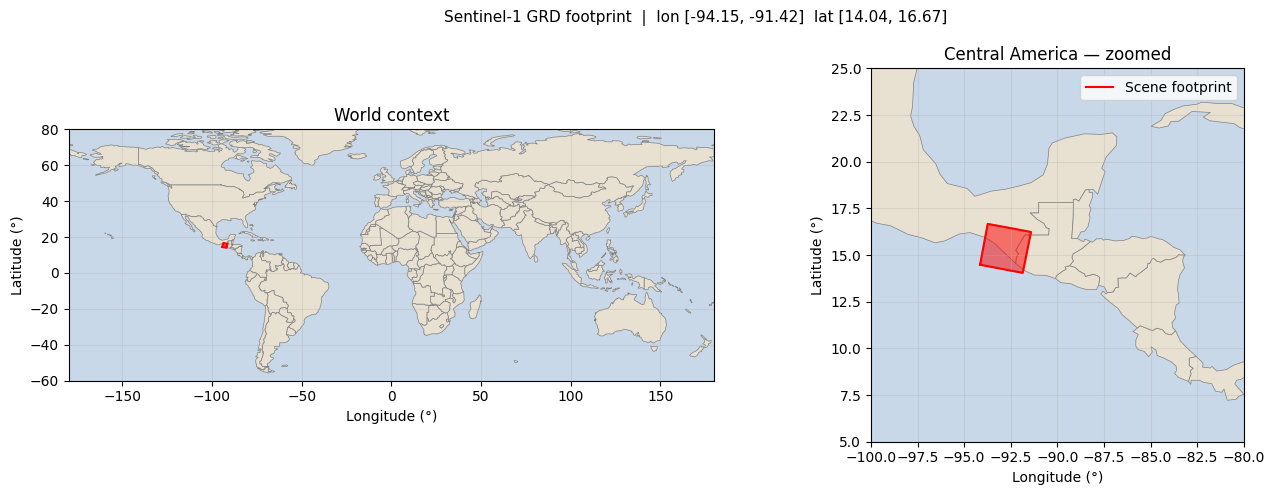

✓ Dataset footprint confirmed over Central America (~-92.8°, 15.3°N)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal
from scipy.spatial import ConvexHull

gdal.UseExceptions()

local_path = "/home/yadagale/work/gdal-zarr-eopf/GDAL-ZARR-EOPF/docs/s1_grd_local.zarr"
ds_local = gdal.Open(f"EOPFZARR:'{local_path}'")
gcps = ds_local.GetGCPs()
ds_local = None

lons = np.array([g.GCPX for g in gcps])
lats = np.array([g.GCPY for g in gcps])

# Convex hull of GCP cloud gives clean scene outline
pts = np.column_stack([lons, lats])
hull = ConvexHull(pts)
hull_lons = np.append(pts[hull.vertices, 0], pts[hull.vertices[0], 0])
hull_lats = np.append(pts[hull.vertices, 1], pts[hull.vertices[0], 1])

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    for ax, extent, title in zip(
        axes,
        [[-180, 180, -60, 80], [-100, -80, 5, 25]],
        ['World context', 'Central America — zoomed'],
    ):
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='#e8e0d0')
        ax.add_feature(cfeature.OCEAN, facecolor='#c8d8e8')
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
        ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        ax.fill(hull_lons, hull_lats, transform=ccrs.PlateCarree(),
                color='red', alpha=0.5)
        ax.plot(hull_lons, hull_lats, transform=ccrs.PlateCarree(),
                color='red', linewidth=1.5, label='Scene footprint')
        ax.set_title(title)

    axes[1].legend(loc='upper right')

except ImportError:
    import geopandas as gpd

    try:
        world = gpd.read_file(
            "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
        )
    except Exception:
        world = None

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, xlim, ylim, title in zip(
        axes,
        [[-180, 180], [-100, -80]],
        [[-60, 80], [5, 25]],
        ['World context', 'Central America — zoomed'],
    ):
        ax.set_facecolor('#c8d8e8')
        if world is not None:
            world.plot(ax=ax, color='#e8e0d0', edgecolor='gray', linewidth=0.5)
        ax.fill(hull_lons, hull_lats, color='red', alpha=0.5)
        ax.plot(hull_lons, hull_lats, color='red', linewidth=1.5, label='Scene footprint')
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xlabel('Longitude (°)')
        ax.set_ylabel('Latitude (°)')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    axes[1].legend(loc='upper right')

plt.suptitle(
    f'Sentinel-1 GRD footprint  |  lon [{lons.min():.2f}, {lons.max():.2f}]'
    f'  lat [{lats.min():.2f}, {lats.max():.2f}]',
    fontsize=11,
)
plt.tight_layout()
plt.show()
print(f"✓ Dataset footprint confirmed over Central America (~{lons.mean():.1f}°, {lats.mean():.1f}°N)")

## Summary

| Check | Result |
|-------|--------|
| Multi-band GRD has GCPs | ✓ |
| GCP SRS is WGS84 | ✓ |
| Warped GRD output in correct location (Central America) | ✓ |
| Both VV and VH bands geolocated | ✓ |
| SLC burst (IW1 VV 001) has GCPs | ✓ |
| SLC burst correctly geolocated (central Italy) | ✓ |

---

## 4. Sentinel-1 SLC — Burst Geolocation

Verifies that an SLC burst opened with `BURST=IW1_VV_001` also carries valid WGS84 GCPs and geolocates correctly.

/home/yadagale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Size:      23261 x 1501
Band type: CFloat32
GCP count: 210
GCP SRS:   WGS 84
Extent:    lon [12.967, 14.482]  lat [40.073, 41.745]

✓ SLC burst has valid WGS84 GCPs
Warped origin: lon=13.3147  lat=40.3989


/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/usr/local/lib/python3.10/dist-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


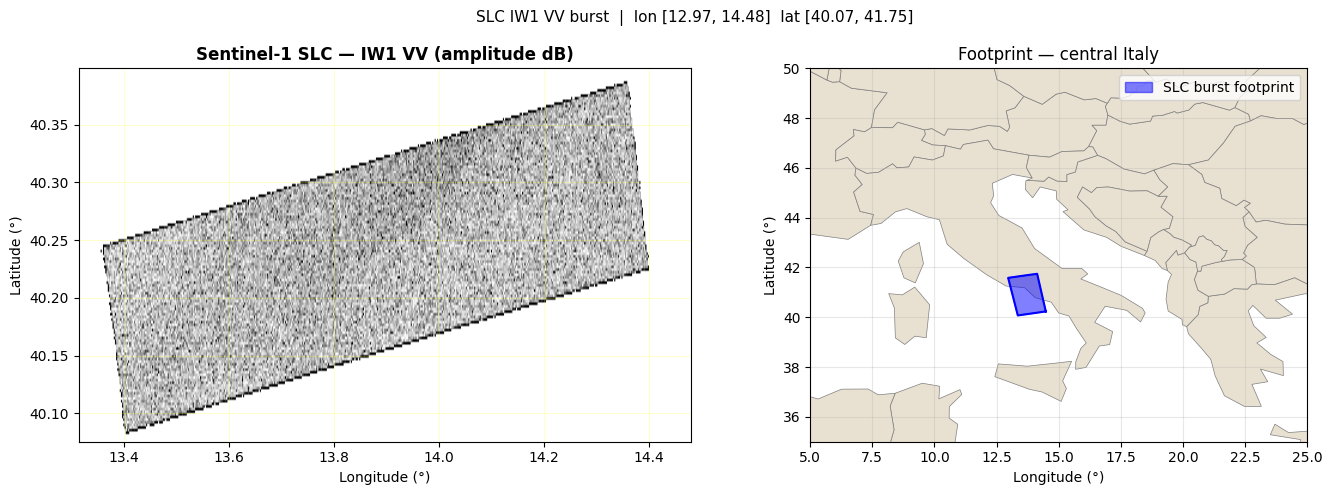

✓ SLC burst correctly geolocated via GCPs


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal
from scipy.spatial import ConvexHull

gdal.UseExceptions()

SLC_URL = (
    "/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "notebook-data/tutorial_data/cpm_v262/"
    "S1C_IW_SLC__1SDV_20251016T165627_20251016T165654_004590_00913B_30C4.zarr"
)

# Open burst IW1 VV 001
ds_slc = gdal.OpenEx(f"EOPFZARR:'{SLC_URL}'", gdal.OF_RASTER, open_options=["BURST=IW1_VV_001"])
assert ds_slc is not None, "Failed to open SLC burst"

print(f"Size:      {ds_slc.RasterXSize} x {ds_slc.RasterYSize}")
print(f"Band type: {gdal.GetDataTypeName(ds_slc.GetRasterBand(1).DataType)}")
print(f"GCP count: {ds_slc.GetGCPCount()}")

srs = ds_slc.GetGCPSpatialRef()
print(f"GCP SRS:   {srs.GetName() if srs else 'NONE'}")
assert ds_slc.GetGCPCount() > 0, "No GCPs!"
assert srs is not None and srs.IsGeographic(), "GCP SRS not geographic!"

gcps = ds_slc.GetGCPs()
lons = [g.GCPX for g in gcps]
lats = [g.GCPY for g in gcps]
print(f"Extent:    lon [{min(lons):.3f}, {max(lons):.3f}]  lat [{min(lats):.3f}, {max(lats):.3f}]")
print("\n✓ SLC burst has valid WGS84 GCPs")

# Warp to EPSG:4326 (downsampled for speed)
warped_slc = gdal.Warp('', ds_slc, format='MEM', dstSRS='EPSG:4326', width=512, height=0, resampleAlg='near')
assert warped_slc is not None, "Warp failed"
gt = warped_slc.GetGeoTransform()
print(f"Warped origin: lon={gt[0]:.4f}  lat={gt[3]:.4f}")

# Visualize amplitude of complex band
try:
    band = warped_slc.GetRasterBand(1)
    if band.DataType in (gdal.GDT_CFloat32, gdal.GDT_CFloat64):
        raw = band.ReadAsArray()
        amplitude = np.abs(raw).astype(np.float32)
    else:
        amplitude = band.ReadAsArray().astype(np.float32)

    amplitude_db = 20 * np.log10(np.where(amplitude > 0, amplitude, np.nan))
    extent = [gt[0], gt[0] + gt[1] * warped_slc.RasterXSize,
              gt[3] + gt[5] * warped_slc.RasterYSize, gt[3]]

    # Footprint from GCPs
    pts = np.column_stack([lons, lats])
    hull = ConvexHull(pts)
    hull_lons = np.append(pts[hull.vertices, 0], pts[hull.vertices[0], 0])
    hull_lats = np.append(pts[hull.vertices, 1], pts[hull.vertices[0], 1])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: amplitude image
    ax = axes[0]
    vmin, vmax = np.nanpercentile(amplitude_db, [2, 98])
    ax.imshow(amplitude_db, cmap='gray', vmin=vmin, vmax=vmax, extent=extent, aspect='auto')
    ax.set_title('Sentinel-1 SLC — IW1 VV (amplitude dB)', fontweight='bold')
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.grid(True, alpha=0.3, color='yellow', linewidth=0.5)

    # Right: footprint map
    ax = axes[1]
    try:
        import geopandas as gpd
        world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
        world.plot(ax=ax, color='#e8e0d0', edgecolor='gray', linewidth=0.5)
    except Exception:
        ax.set_facecolor('#c8d8e8')

    ax.fill(hull_lons, hull_lats, color='blue', alpha=0.5, label='SLC burst footprint')
    ax.plot(hull_lons, hull_lats, color='blue', linewidth=1.5)
    ax.set_xlim(5, 25)
    ax.set_ylim(35, 50)
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.set_title('Footprint — central Italy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'SLC IW1 VV burst  |  lon [{min(lons):.2f}, {max(lons):.2f}]  lat [{min(lats):.2f}, {max(lats):.2f}]',
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
    print("✓ SLC burst correctly geolocated via GCPs")

except Exception as e:
    print(f"Plot skipped: {e}")

warped_slc = None
ds_slc = None

Total GCP points from all bursts: 11340
Full scene extent: lon [12.967, 16.356]  lat [40.073, 42.102]


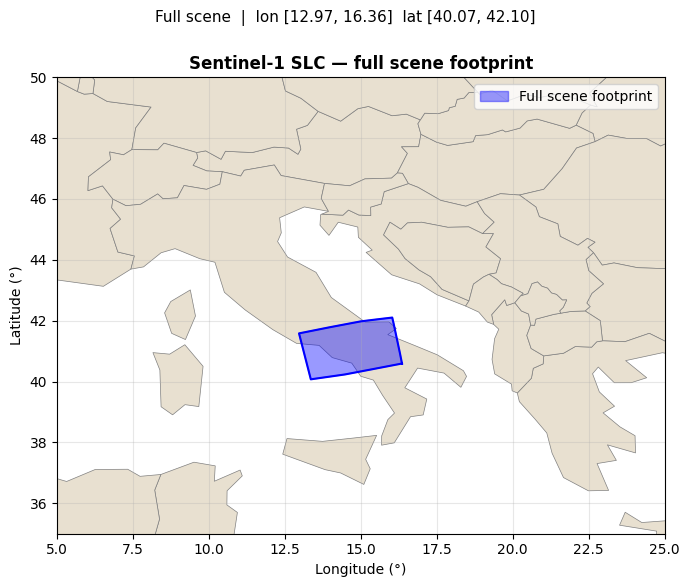

In [2]:
from scipy.spatial import ConvexHull
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

gdal.UseExceptions()

SLC_URL = (
    "/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "notebook-data/tutorial_data/cpm_v262/"
    "S1C_IW_SLC__1SDV_20251016T165627_20251016T165654_004590_00913B_30C4.zarr"
)

# Open root (no BURST) to get full scene subdatasets and collect all GCPs
ds_root = gdal.Open(f"EOPFZARR:'{SLC_URL}'")
subdatasets = ds_root.GetMetadata("SUBDATASETS") or {}
ds_root = None

all_lons, all_lats = [], []

for k, v in subdatasets.items():
    if "_NAME" not in k:
        continue
    # Open each measurement subdataset and collect its GCPs
    if "measurements/slc" not in v:
        continue
    ds_sub = gdal.Open(v)
    if ds_sub is None:
        continue
    gcps = ds_sub.GetGCPs()
    all_lons.extend(g.GCPX for g in gcps)
    all_lats.extend(g.GCPY for g in gcps)
    ds_sub = None

print(f"Total GCP points from all bursts: {len(all_lons)}")
print(f"Full scene extent: lon [{min(all_lons):.3f}, {max(all_lons):.3f}]  lat [{min(all_lats):.3f}, {max(all_lats):.3f}]")

pts = np.column_stack([all_lons, all_lats])
hull = ConvexHull(pts)
hull_lons = np.append(pts[hull.vertices, 0], pts[hull.vertices[0], 0])
hull_lats = np.append(pts[hull.vertices, 1], pts[hull.vertices[0], 1])

fig, ax = plt.subplots(figsize=(7, 6))

try:
    import geopandas as gpd
    world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
    world.plot(ax=ax, color='#e8e0d0', edgecolor='gray', linewidth=0.5)
except Exception:
    ax.set_facecolor('#c8d8e8')

ax.fill(hull_lons, hull_lats, color='blue', alpha=0.4, label='Full scene footprint')
ax.plot(hull_lons, hull_lats, color='blue', linewidth=1.5)
ax.set_xlim(5, 25)
ax.set_ylim(35, 50)
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Sentinel-1 SLC — full scene footprint', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Full scene  |  lon [{min(all_lons):.2f}, {max(all_lons):.2f}]  lat [{min(all_lats):.2f}, {max(all_lats):.2f}]',
    fontsize=11,
)
plt.tight_layout()
plt.show()